In [1]:
from IPython.display import display, Markdown
import pandas as pd
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..') / 'src'))
from cleaning import filter_clean

# Calcular stats del dataset para el header dinámico
_df = pd.read_parquet(Path('..') / 'data' / 'processed' / 'sessions.parquet')
_df_clean = filter_clean(_df, verbose=False)
_n = len(_df_clean)
_wins = int(_df_clean['isVictory'].sum())
_losses = _n - _wins
_ratio = round(_losses / _wins, 2) if _wins > 0 else '∞'

display(Markdown(f"""
# Fase 4a — Modelo Predictivo de Victoria + Clustering

Predice `isVictory` (clasificación binaria) a partir de métricas de rendimiento del jugador.
Complementa con K-Means para identificar perfiles de estilo de juego.

**Entradas:** `data/processed/sessions.parquet`, `rooms.parquet`  
**Salidas:** `data/exports/ml_predictions.csv`, `player_clusters.csv`, modelos en `models/`

> **Limitación crítica:** n={_n} sesiones ({_wins} victorias / {_losses} derrotas). Desequilibrio de clases 1:{_ratio}.
> Todos los resultados son **orientativos**. Con n<30 por clase los modelos no son generalizables.
> Se usa **Leave-One-Out** como estrategia de validación para maximizar el uso de los datos.
"""))


# Fase 4a — Modelo Predictivo de Victoria + Clustering

Predice `isVictory` (clasificación binaria) a partir de métricas de rendimiento del jugador.
Complementa con K-Means para identificar perfiles de estilo de juego.

**Entradas:** `data/processed/sessions.parquet`, `rooms.parquet`  
**Salidas:** `data/exports/ml_predictions.csv`, `player_clusters.csv`, modelos en `models/`

> **Limitación crítica:** n=39 sesiones (12 victorias / 27 derrotas). Desequilibrio de clases 1:2.25.
> Todos los resultados son **orientativos**. Con n<30 por clase los modelos no son generalizables.
> Se usa **Leave-One-Out** como estrategia de validación para maximizar el uso de los datos.


## 0. Configuración

In [2]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              confusion_matrix, classification_report, roc_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from xgboost import XGBClassifier
from scipy.stats import entropy as scipy_entropy

# SHAP (mejora G)
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP no disponible — instalar con: pip install shap')

sys.path.insert(0, str(Path('..') / 'src'))
from preprocessing import compute_spell_usage_ratios
from cleaning import filter_clean
from visualization import PALETTE_ELEM

PROCESSED_DIR = Path('..') / 'data' / 'processed'
EXPORTS_DIR   = Path('..') / 'data' / 'exports'
FIGURES_DIR   = Path('..') / 'reports' / 'figures'
MODELS_DIR    = Path('..') / 'models'
for d in [EXPORTS_DIR, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas correctamente')

SHAP no disponible — instalar con: pip install shap
Librerías cargadas correctamente


## 1. Feature matrix — TFM-14, TFM-39

In [3]:
df_sessions = pd.read_parquet(PROCESSED_DIR / 'sessions.parquet')
df_rooms    = pd.read_parquet(PROCESSED_DIR / 'rooms.parquet')

# cast_accuracy media por sesión
cast_acc = df_rooms.groupby('sessionId')['cast_accuracy'].mean().rename('cast_accuracy')
df_sessions = df_sessions.merge(cast_acc, on='sessionId', how='left')

# Filtrar sesiones sospechosas
df_clean = filter_clean(df_sessions, verbose=True)
print(f'Victorias: {df_clean["isVictory"].sum()} / {len(df_clean)} ({df_clean["isVictory"].mean():.1%})')

filter_clean: 39 sesiones limpias de 58 totales (19 sospechosas eliminadas)
Victorias: 12 / 39 (30.8%)


In [4]:
# Ratios de uso de hechizos por sesión
df_ratios = compute_spell_usage_ratios(df_rooms, df_clean)
df_model  = df_clean.merge(df_ratios, on='sessionId', how='left')

ratio_cols = [c for c in df_model.columns if c.startswith('ratio_cast_')]
print('Features de hechizos:', ratio_cols)

# --- Mejora E: diversidad de hechizos ---
cast_spell_cols = [c for c in df_rooms.columns if c.startswith('cast_')]
spell_sess = df_rooms.groupby('sessionId')[cast_spell_cols].sum().reset_index()

def spell_entropy_fn(row):
    vals = row[cast_spell_cols].values.astype(float)
    total = vals.sum()
    if total == 0: return 0.0
    probs = vals / total
    return float(scipy_entropy(probs[probs > 0]))

spell_sess['n_spells_used']  = (spell_sess[cast_spell_cols] > 0).sum(axis=1)
spell_sess['spell_entropy']  = spell_sess.apply(spell_entropy_fn, axis=1)
df_model = df_model.merge(
    spell_sess[['sessionId', 'n_spells_used', 'spell_entropy']], on='sessionId', how='left'
)

# --- Mejora A: status effects y bloqueos como features ---
status_cols_rooms  = [c for c in df_rooms.columns if c.startswith('status_')]
blocked_cols_rooms = [c for c in df_rooms.columns if c.startswith('blocked_')]

if status_cols_rooms:
    status_agg = df_rooms.groupby('sessionId')[status_cols_rooms].sum().reset_index()
    df_model = df_model.merge(status_agg, on='sessionId', how='left')

if blocked_cols_rooms:
    blocked_agg = df_rooms.groupby('sessionId')[blocked_cols_rooms].sum()
    blocked_agg['total_blocked'] = blocked_agg.sum(axis=1)
    df_model = df_model.merge(blocked_agg[['total_blocked']], on='sessionId', how='left')

# --- Mejora F: excluir variables de salida ---
# levelsCompleted y totalRooms son consecuencia de ganar, no causa.
# Se incluyen en un set separado para comparación pero NO en el modelo principal.
OUTPUT_FEATURES = ['levelsCompleted', 'totalRooms']

BASE_FEATURES = ['kd_ratio', 'kills_per_min', 'time_per_level', 'cast_accuracy',
                 'totalCast', 'totalDeaths']
DIVERSITY_FEATURES = ['n_spells_used', 'spell_entropy']
STATUS_FEATURES    = [c for c in status_cols_rooms if c in df_model.columns]
BLOCKED_FEATURES   = ['total_blocked'] if 'total_blocked' in df_model.columns else []

FEATURES = BASE_FEATURES + ratio_cols + DIVERSITY_FEATURES + STATUS_FEATURES + BLOCKED_FEATURES
TARGET   = 'isVictory'

print(f'\nFeatures causales ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  {f}')
print(f'\n[Excluidas como variables de salida: {OUTPUT_FEATURES}]')

df_ml = df_model[['sessionId', 'playerElement'] + FEATURES + [TARGET]].dropna()
X = df_ml[FEATURES].values
y = df_ml[TARGET].astype(int).values

print(f'\nMuestras: {len(X)}  |  Victorias: {y.sum()}  |  Derrotas: {(y==0).sum()}')

Features de hechizos: ['ratio_cast_Blast', 'ratio_cast_Projectile', 'ratio_cast_Beam', 'ratio_cast_AOE', 'ratio_cast_Shield', 'ratio_cast_Aura']

Features causales (19):
  kd_ratio
  kills_per_min
  time_per_level
  cast_accuracy
  totalCast
  totalDeaths
  ratio_cast_Blast
  ratio_cast_Projectile
  ratio_cast_Beam
  ratio_cast_AOE
  ratio_cast_Shield
  ratio_cast_Aura
  n_spells_used
  spell_entropy
  status_Burn
  status_Stun
  status_Slow
  status_Knockback
  total_blocked

[Excluidas como variables de salida: ['levelsCompleted', 'totalRooms']]

Muestras: 39  |  Victorias: 12  |  Derrotas: 27


In [5]:
# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print('Scaler guardado en models/scaler.pkl')

Scaler guardado en models/scaler.pkl


## 2. Logistic Regression baseline — TFM-39

In [6]:
loo = LeaveOneOut()

# LOO cross-validation para LR
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
y_pred_lr  = cross_val_predict(lr, X_scaled, y, cv=loo)
y_proba_lr = cross_val_predict(lr, X_scaled, y, cv=loo, method='predict_proba')[:, 1]

auc_lr = roc_auc_score(y, y_proba_lr)
f1_lr  = f1_score(y, y_pred_lr, average='macro', zero_division=0)
acc_lr = accuracy_score(y, y_pred_lr)

print('=== Logistic Regression (LOO) ===')
print(f'AUC: {auc_lr:.3f}  |  F1 macro: {f1_lr:.3f}  |  Accuracy: {acc_lr:.3f}')
print(classification_report(y, y_pred_lr, target_names=['Derrota','Victoria'], zero_division=0))

=== Logistic Regression (LOO) ===
AUC: 0.972  |  F1 macro: 0.940  |  Accuracy: 0.949
              precision    recall  f1-score   support

     Derrota       0.96      0.96      0.96        27
    Victoria       0.92      0.92      0.92        12

    accuracy                           0.95        39
   macro avg       0.94      0.94      0.94        39
weighted avg       0.95      0.95      0.95        39



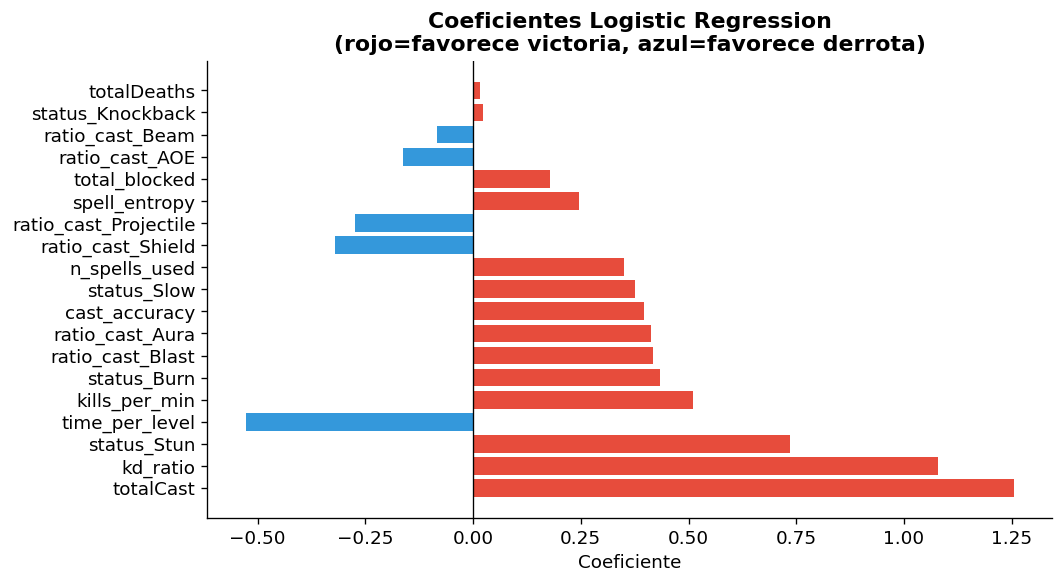

In [7]:
# Coeficientes LR (entrenado en todo el dataset para interpretación)
lr_full = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
lr_full.fit(X_scaled, y)

coef_df = pd.DataFrame({'feature': FEATURES, 'coef': lr_full.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes Logistic Regression\n(rojo=favorece victoria, azul=favorece derrota)', fontweight='bold')
ax.set_xlabel('Coeficiente')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5_0_lr_coeficientes.png', bbox_inches='tight')
plt.show()

## 3. Random Forest y XGBoost — TFM-14

In [8]:
# Random Forest con LOO
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
y_pred_rf  = cross_val_predict(rf, X_scaled, y, cv=loo)
y_proba_rf = cross_val_predict(rf, X_scaled, y, cv=loo, method='predict_proba')[:, 1]

auc_rf = roc_auc_score(y, y_proba_rf)
f1_rf  = f1_score(y, y_pred_rf, average='macro', zero_division=0)
acc_rf = accuracy_score(y, y_pred_rf)

print('=== Random Forest (LOO) ===')
print(f'AUC: {auc_rf:.3f}  |  F1 macro: {f1_rf:.3f}  |  Accuracy: {acc_rf:.3f}')
print(classification_report(y, y_pred_rf, target_names=['Derrota','Victoria'], zero_division=0))

=== Random Forest (LOO) ===
AUC: 0.986  |  F1 macro: 0.902  |  Accuracy: 0.923
              precision    recall  f1-score   support

     Derrota       0.90      1.00      0.95        27
    Victoria       1.00      0.75      0.86        12

    accuracy                           0.92        39
   macro avg       0.95      0.88      0.90        39
weighted avg       0.93      0.92      0.92        39



In [9]:
# XGBoost con LOO
# scale_pos_weight para desequilibrio de clases
scale_pw = int((y == 0).sum() / max(y.sum(), 1))
xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                    scale_pos_weight=scale_pw, eval_metric='logloss',
                    random_state=42, verbosity=0)
y_pred_xgb  = cross_val_predict(xgb, X_scaled, y, cv=loo)
y_proba_xgb = cross_val_predict(xgb, X_scaled, y, cv=loo, method='predict_proba')[:, 1]

auc_xgb = roc_auc_score(y, y_proba_xgb)
f1_xgb  = f1_score(y, y_pred_xgb, average='macro', zero_division=0)
acc_xgb = accuracy_score(y, y_pred_xgb)

print('=== XGBoost (LOO) ===')
print(f'AUC: {auc_xgb:.3f}  |  F1 macro: {f1_xgb:.3f}  |  Accuracy: {acc_xgb:.3f}')
print(classification_report(y, y_pred_xgb, target_names=['Derrota','Victoria'], zero_division=0))

=== XGBoost (LOO) ===
AUC: 0.972  |  F1 macro: 0.880  |  Accuracy: 0.897
              precision    recall  f1-score   support

     Derrota       0.93      0.93      0.93        27
    Victoria       0.83      0.83      0.83        12

    accuracy                           0.90        39
   macro avg       0.88      0.88      0.88        39
weighted avg       0.90      0.90      0.90        39



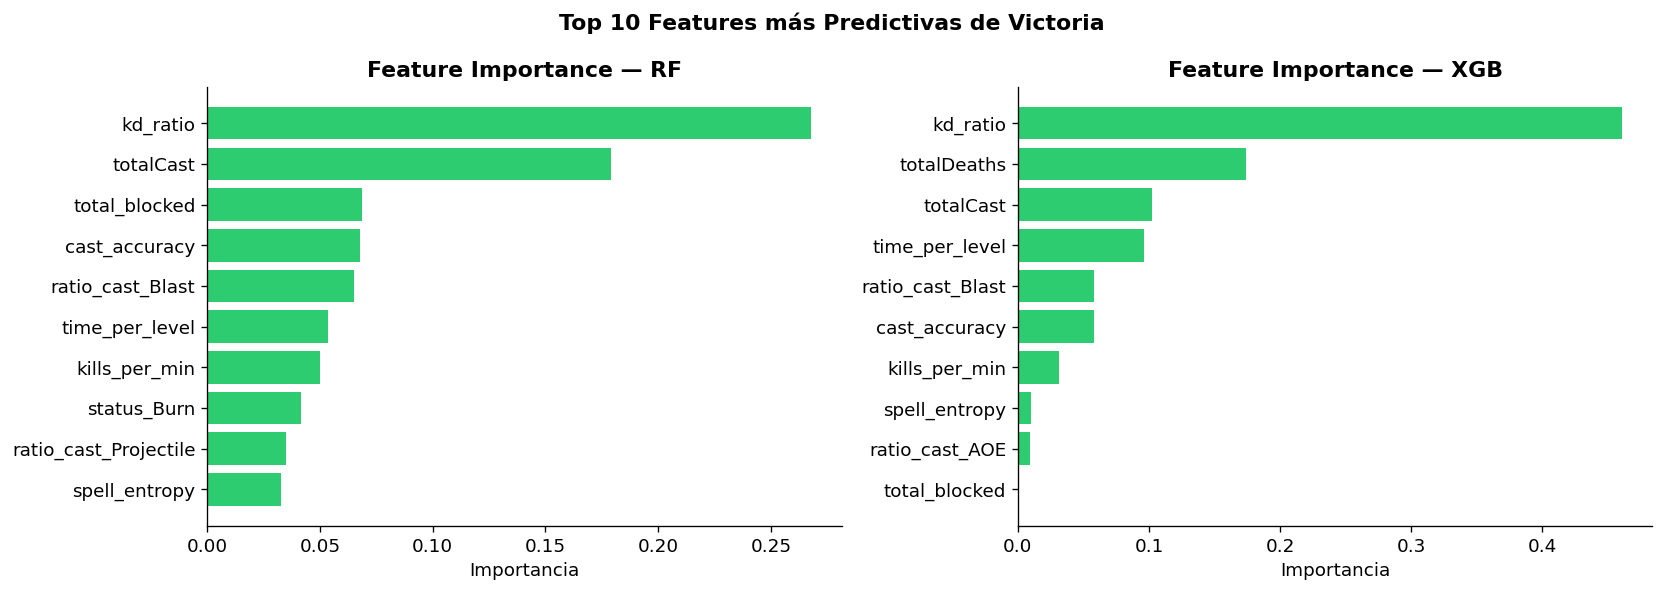

fig5_1_feature_importance.png guardado


In [10]:
# Feature importance RF y XGB
rf_full  = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_full.fit(X_scaled, y)
xgb_full = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                         scale_pos_weight=scale_pw, eval_metric='logloss',
                         random_state=42, verbosity=0)
xgb_full.fit(X_scaled, y)

import_df = pd.DataFrame({
    'feature'   : FEATURES,
    'RF'        : rf_full.feature_importances_,
    'XGB'       : xgb_full.feature_importances_,
}).sort_values('RF', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model_name in zip(axes, ['RF', 'XGB']):
    top = import_df.nlargest(10, model_name)
    ax.barh(top['feature'], top[model_name], color='#2ecc71')
    ax.set_title(f'Feature Importance — {model_name}', fontweight='bold')
    ax.set_xlabel('Importancia')
    ax.invert_yaxis()
fig.suptitle('Top 10 Features más Predictivas de Victoria', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5_1_feature_importance.png', bbox_inches='tight')
plt.show()
print('fig5_1_feature_importance.png guardado')

In [11]:
# Exportar feature importances para el dashboard interactivo
import_df.to_csv(EXPORTS_DIR / 'feature_importances.csv', index=False)
print('feature_importances.csv guardado')

feature_importances.csv guardado


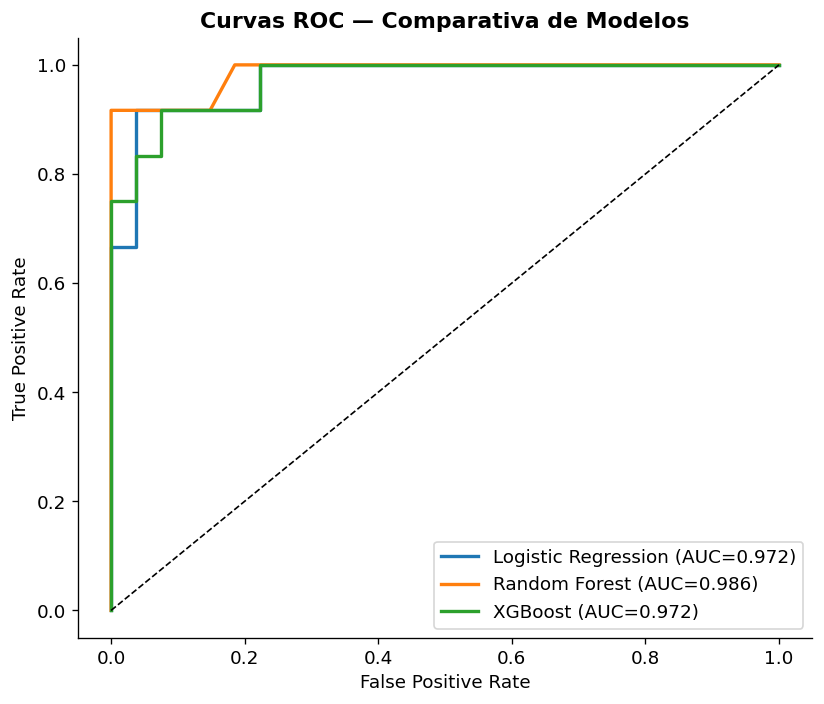

fig5_2_roc_curves.png guardado


In [12]:
# Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in [('Logistic Regression', y_proba_lr),
                    ('Random Forest', y_proba_rf),
                    ('XGBoost', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y, proba)
    auc = roc_auc_score(y, proba)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Comparativa de Modelos', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5_2_roc_curves.png', bbox_inches='tight')
plt.show()
print('fig5_2_roc_curves.png guardado')

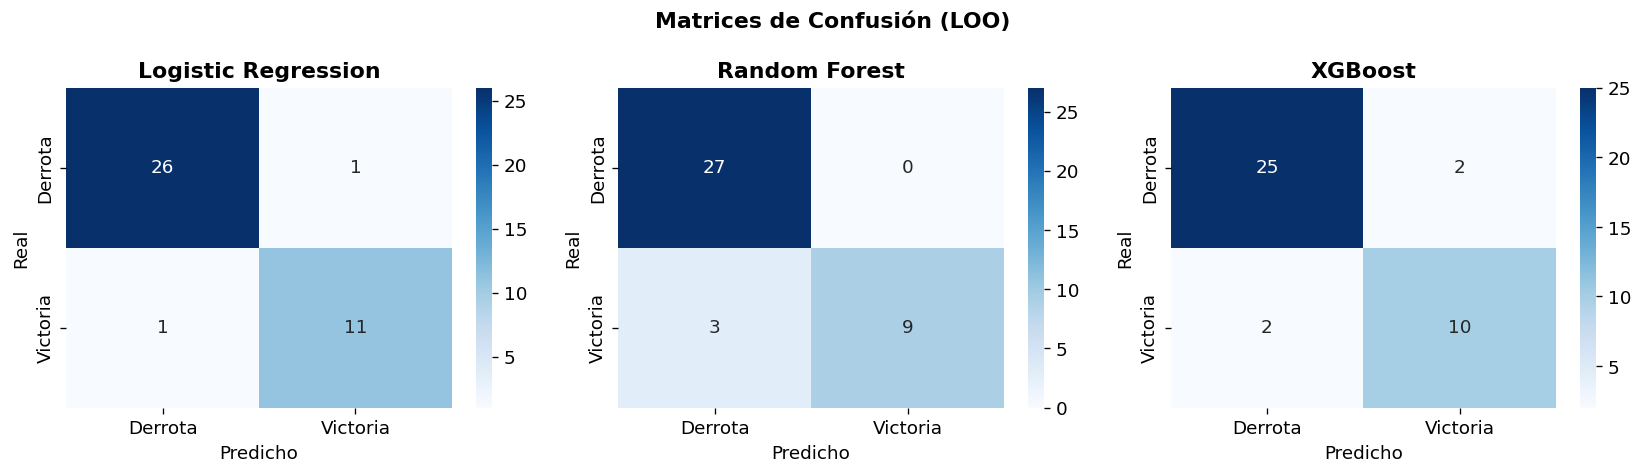

fig5_3_confusion_matrices.png guardado


In [13]:
# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                    ('Random Forest', y_pred_rf),
                                    ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Derrota','Victoria'],
                yticklabels=['Derrota','Victoria'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
fig.suptitle('Matrices de Confusión (LOO)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5_3_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('fig5_3_confusion_matrices.png guardado')

## 4. Optuna — Hyperparameter tuning XGBoost — TFM-40

In [14]:
def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 300),
        'max_depth'       : trial.suggest_int('max_depth', 2, 6),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': scale_pw,
        'eval_metric'     : 'logloss',
        'random_state'    : 42,
        'verbosity'       : 0,
    }
    model = XGBClassifier(**params)
    # StratifiedKFold con n_splits=3 (máximo viable con n=24, 5 positivos)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_scaled, y):
        model.fit(X_scaled[train_idx], y[train_idx])
        proba = model.predict_proba(X_scaled[val_idx])[:, 1]
        if len(np.unique(y[val_idx])) > 1:
            scores.append(roc_auc_score(y[val_idx], proba))
    return np.mean(scores) if scores else 0.5

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f'Mejor AUC (CV): {study.best_value:.3f}')
print(f'Mejores parámetros: {study.best_params}')

Mejor AUC (CV): 1.000
Mejores parámetros: {'n_estimators': 154, 'max_depth': 4, 'learning_rate': 0.29940478106623586, 'subsample': 0.9785517411659675, 'colsample_bytree': 0.547356566737599}


In [15]:
# Reentrenar XGB con mejores parámetros y evaluar con LOO
best_params = study.best_params
best_params.update({'scale_pos_weight': scale_pw, 'eval_metric': 'logloss',
                    'random_state': 42, 'verbosity': 0})
xgb_tuned = XGBClassifier(**best_params)

y_pred_xgb_t  = cross_val_predict(xgb_tuned, X_scaled, y, cv=loo)
y_proba_xgb_t = cross_val_predict(xgb_tuned, X_scaled, y, cv=loo, method='predict_proba')[:, 1]

auc_xgb_t = roc_auc_score(y, y_proba_xgb_t)
f1_xgb_t  = f1_score(y, y_pred_xgb_t, average='macro', zero_division=0)
acc_xgb_t = accuracy_score(y, y_pred_xgb_t)

print(f'XGBoost base   → AUC: {auc_xgb:.3f}  F1: {f1_xgb:.3f}')
print(f'XGBoost tuned  → AUC: {auc_xgb_t:.3f}  F1: {f1_xgb_t:.3f}')

XGBoost base   → AUC: 0.972  F1: 0.880
XGBoost tuned  → AUC: 0.985  F1: 0.880


## 5. Comparación y mejor modelo — TFM-15

In [16]:
results = pd.DataFrame([
    {'modelo': 'Logistic Regression', 'AUC': auc_lr,    'F1_macro': f1_lr,    'Accuracy': acc_lr},
    {'modelo': 'Random Forest',       'AUC': auc_rf,    'F1_macro': f1_rf,    'Accuracy': acc_rf},
    {'modelo': 'XGBoost',             'AUC': auc_xgb,   'F1_macro': f1_xgb,   'Accuracy': acc_xgb},
    {'modelo': 'XGBoost (tuned)',      'AUC': auc_xgb_t, 'F1_macro': f1_xgb_t, 'Accuracy': acc_xgb_t},
]).sort_values('AUC', ascending=False).reset_index(drop=True)

print('=== Tabla comparativa de modelos (LOO) ===')
print(results.round(3).to_string(index=False))

best_name = results.iloc[0]['modelo']
print(f'\nMejor modelo: {best_name} (AUC={results.iloc[0]["AUC"]:.3f})')

=== Tabla comparativa de modelos (LOO) ===
             modelo   AUC  F1_macro  Accuracy
      Random Forest 0.986     0.902     0.923
    XGBoost (tuned) 0.985     0.880     0.897
Logistic Regression 0.972     0.940     0.949
            XGBoost 0.972     0.880     0.897

Mejor modelo: Random Forest (AUC=0.986)


In [17]:
# Serializar modelos entrenados en todo el dataset
lr_full.fit(X_scaled, y)
rf_full.fit(X_scaled, y)
xgb_tuned_full = XGBClassifier(**best_params)
xgb_tuned_full.fit(X_scaled, y)

joblib.dump(lr_full,        MODELS_DIR / 'logistic_regression.pkl')
joblib.dump(rf_full,        MODELS_DIR / 'random_forest.pkl')
joblib.dump(xgb_tuned_full, MODELS_DIR / 'xgboost_model.pkl')
print('Modelos guardados en models/')

Modelos guardados en models/


## 5b. SHAP values — interpretabilidad del mejor modelo

In [18]:
# SHAP values — Random Forest (mejor modelo) entrenado en todo el dataset
if SHAP_AVAILABLE:
    explainer   = shap.TreeExplainer(rf_full)
    shap_values = explainer.shap_values(X_scaled)

    # shap_values es lista [clase_0, clase_1] para clasificación binaria
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('SHAP Values — Random Forest (interpretabilidad)', fontweight='bold')

    # Summary plot (beeswarm)
    plt.sca(axes[0])
    shap.summary_plot(sv, X_scaled, feature_names=FEATURES, show=False,
                      plot_type='dot', max_display=15)
    axes[0].set_title('Impacto de cada feature en la predicción\n(rojo=valor alto, azul=valor bajo)',
                       fontweight='bold')

    # Bar plot (importancia media |SHAP|)
    mean_shap = np.abs(sv).mean(axis=0)
    shap_df = pd.DataFrame({'feature': FEATURES, 'mean_|shap|': mean_shap})\
                .sort_values('mean_|shap|', ascending=True)
    axes[1].barh(shap_df['feature'], shap_df['mean_|shap|'], color='#3498db', alpha=0.85)
    axes[1].set_xlabel('Media |SHAP value|')
    axes[1].set_title('Importancia global (|SHAP| medio)', fontweight='bold')

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'fig5_6_shap_values.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('fig5_6_shap_values.png guardado')

    # Top 5 features por SHAP
    top_shap = shap_df.sort_values('mean_|shap|', ascending=False).head(5)
    print('\nTop 5 features por SHAP (causales, sin variables de salida):')
    print(top_shap.to_string(index=False))
else:
    print('SHAP no disponible — omitiendo bloque. Instalar: pip install shap')

SHAP no disponible — omitiendo bloque. Instalar: pip install shap


## 5c. Threshold tuning — optimizar recall de victorias

Threshold por defecto (0.5):
 threshold  f1_victoria  f1_derrota  f1_macro  accuracy
       0.5     0.857143    0.947368  0.902256  0.923077

Mejor threshold para F1 macro: 0.42
 threshold  f1_victoria  f1_derrota  f1_macro  accuracy
      0.42     0.956522    0.981818   0.96917  0.974359


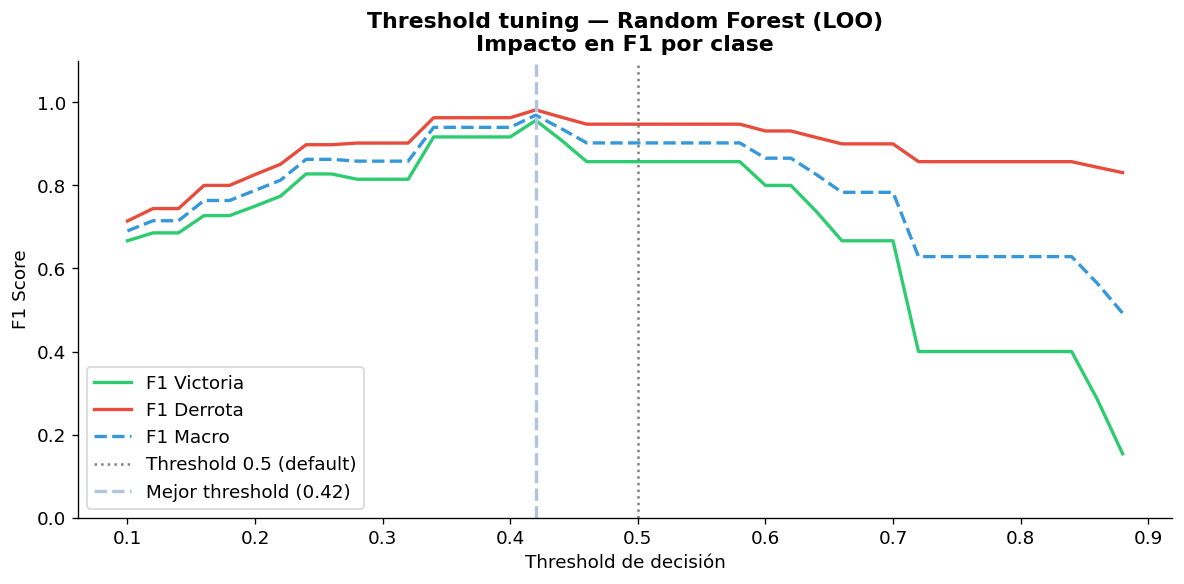

fig5_7_threshold_tuning.png guardado

=== Clasificación con threshold=0.42 ===
              precision    recall  f1-score   support

     Derrota       0.96      0.96      0.96        27
    Victoria       0.92      0.92      0.92        12

    accuracy                           0.95        39
   macro avg       0.94      0.94      0.94        39
weighted avg       0.95      0.95      0.95        39



In [19]:
# Threshold tuning — con clases desbalanceadas (1:4) el umbral 0.5 sesga hacia derrota.
# Buscamos el umbral que maximiza F1 de la clase Victoria (LOO probabilidades del RF).
from sklearn.metrics import precision_recall_curve

thresholds_range = np.arange(0.1, 0.9, 0.02)
results_thresh = []
for thr in thresholds_range:
    y_pred_thr = (y_proba_rf >= thr).astype(int)
    f1_vic = f1_score(y, y_pred_thr, pos_label=1, zero_division=0)
    f1_der = f1_score(y, y_pred_thr, pos_label=0, zero_division=0)
    f1_mac = f1_score(y, y_pred_thr, average='macro', zero_division=0)
    acc    = accuracy_score(y, y_pred_thr)
    results_thresh.append({'threshold': round(thr, 2), 'f1_victoria': f1_vic,
                           'f1_derrota': f1_der, 'f1_macro': f1_mac, 'accuracy': acc})

df_thresh = pd.DataFrame(results_thresh)
best_thr_row = df_thresh.loc[df_thresh['f1_macro'].idxmax()]
best_thr = best_thr_row['threshold']

print(f'Threshold por defecto (0.5):')
print(df_thresh[df_thresh['threshold'] == 0.50].to_string(index=False))
print(f'\nMejor threshold para F1 macro: {best_thr}')
print(df_thresh[df_thresh['threshold'] == best_thr].to_string(index=False))

# Figura: F1 victoria y derrota vs threshold
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh['threshold'], df_thresh['f1_victoria'], label='F1 Victoria', color='#2ecc71', linewidth=2)
ax.plot(df_thresh['threshold'], df_thresh['f1_derrota'],  label='F1 Derrota',  color='#e74c3c', linewidth=2)
ax.plot(df_thresh['threshold'], df_thresh['f1_macro'],    label='F1 Macro',    color='#3498db', linewidth=2, linestyle='--')
ax.axvline(0.5,      color='gray',   linestyle=':', linewidth=1.5, label='Threshold 0.5 (default)')
ax.axvline(best_thr, color='#B0C4DE', linestyle='--', linewidth=2, label=f'Mejor threshold ({best_thr})')
ax.set_xlabel('Threshold de decisión')
ax.set_ylabel('F1 Score')
ax.set_title('Threshold tuning — Random Forest (LOO)\nImpacto en F1 por clase', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5_7_threshold_tuning.png', bbox_inches='tight', dpi=150)
plt.show()
print('fig5_7_threshold_tuning.png guardado')

# Reporte con umbral óptimo
print(f'\n=== Clasificación con threshold={best_thr} ===')
y_pred_opt = (y_proba_rf >= best_thr).astype(int)
print(classification_report(y, y_pred_opt, target_names=['Derrota','Victoria'], zero_division=0))

In [20]:
# Exportar predicciones
df_pred = df_ml[['sessionId', 'playerElement', TARGET]].copy()
df_pred['y_real']     = y
df_pred['proba_lr']   = y_proba_lr
df_pred['proba_rf']   = y_proba_rf
df_pred['proba_xgb']  = y_proba_xgb_t
df_pred['pred_best']  = y_pred_xgb_t  # mejor modelo
df_pred.to_csv(EXPORTS_DIR / 'ml_predictions.csv', index=False)
print('ml_predictions.csv guardado')

ml_predictions.csv guardado


## 6. K-Means Clustering — TFM-15

In [21]:
# Silhouette score para k=2..6
sil_scores = []
K_RANGE = range(2, 7)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f'k={k}  Silhouette={sil:.3f}')

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\nk óptimo: {best_k} (Silhouette={max(sil_scores):.3f})')

k=2  Silhouette=0.159
k=3  Silhouette=0.152
k=4  Silhouette=0.155
k=5  Silhouette=0.174
k=6  Silhouette=0.187

k óptimo: 6 (Silhouette=0.187)


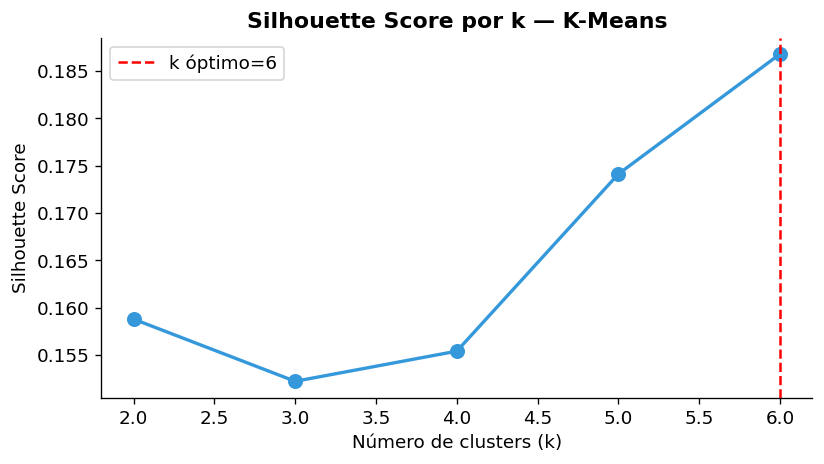

fig5_4_silhouette.png guardado


In [22]:
# Gráfico silhouette
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_RANGE), sil_scores, 'o-', color='#3498db', linewidth=2, markersize=8)
ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'k óptimo={best_k}')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score por k — K-Means', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5_4_silhouette.png', bbox_inches='tight')
plt.show()
print('fig5_4_silhouette.png guardado')

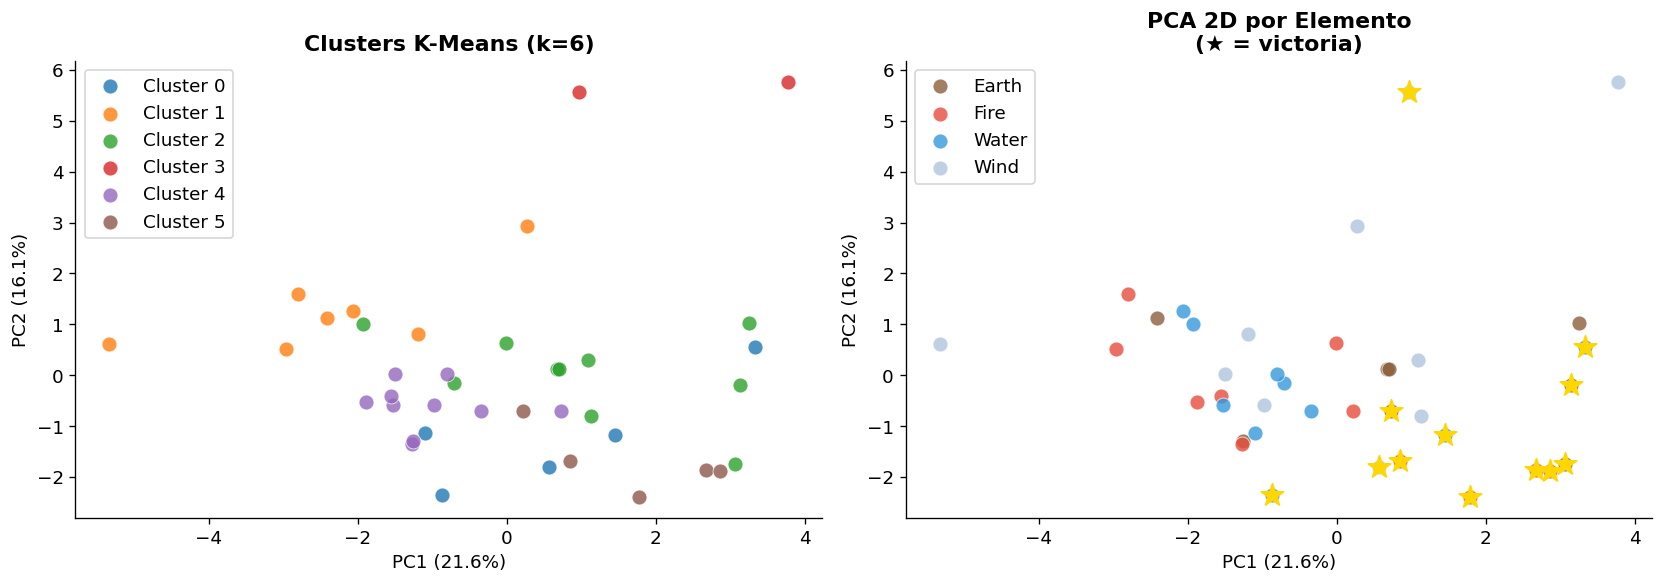

fig5_5_cluster_scatter.png guardado


In [23]:
# K-Means con k óptimo
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)
df_ml = df_ml.copy()
df_ml['cluster'] = cluster_labels

# PCA 2D para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['cluster'] = cluster_labels
df_pca['playerElement'] = df_ml['playerElement'].values
df_pca['isVictory'] = y

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por cluster
for c in range(best_k):
    mask = df_pca['cluster'] == c
    axes[0].scatter(df_pca.loc[mask,'PC1'], df_pca.loc[mask,'PC2'],
                    label=f'Cluster {c}', s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
axes[0].set_title(f'Clusters K-Means (k={best_k})', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend()

# Por elemento
for elem, grp in df_pca.groupby('playerElement'):
    marker = '*' if grp['isVictory'].any() else 'o'
    axes[1].scatter(grp['PC1'], grp['PC2'], label=elem,
                    color=PALETTE_ELEM.get(elem,'#888'), s=80,
                    alpha=0.8, edgecolors='white', linewidths=0.5)
    # Marcar victorias con estrella
    wins = grp[grp['isVictory'] == 1]
    if len(wins):
        axes[1].scatter(wins['PC1'], wins['PC2'], color='gold', s=200,
                        marker='*', zorder=5, label=None)
axes[1].set_title('PCA 2D por Elemento\n(★ = victoria)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5_5_cluster_scatter.png', bbox_inches='tight')
plt.show()
print('fig5_5_cluster_scatter.png guardado')

In [24]:
# Perfil de cada cluster
print('=== Perfil de clusters ===')
for c in range(best_k):
    mask = df_ml['cluster'] == c
    subdf = df_ml[mask]
    print(f'\nCluster {c} (n={mask.sum()}):')
    print(f'  Victorias : {subdf["isVictory"].sum()} ({subdf["isVictory"].mean():.0%})')
    print(f'  Elementos : {subdf["playerElement"].value_counts().to_dict()}')
    print(f'  kd_ratio  : {subdf["kd_ratio"].mean():.2f} (media)')
    print(f'  kills/min : {subdf["kills_per_min"].mean():.2f} (media)')
    print(f'  cast_acc  : {subdf["cast_accuracy"].mean():.2f} (media)')

=== Perfil de clusters ===

Cluster 0 (n=5):
  Victorias : 4 (80%)
  Elementos : {'Water': 4, 'Wind': 1}
  kd_ratio  : 95.80 (media)
  kills/min : 4.12 (media)
  cast_acc  : 0.88 (media)

Cluster 1 (n=7):
  Victorias : 0 (0%)
  Elementos : {'Wind': 3, 'Fire': 2, 'Water': 1, 'Earth': 1}
  kd_ratio  : 15.14 (media)
  kills/min : 3.90 (media)
  cast_acc  : 0.76 (media)

Cluster 2 (n=10):
  Victorias : 2 (20%)
  Elementos : {'Earth': 5, 'Water': 2, 'Wind': 2, 'Fire': 1}
  kd_ratio  : 46.50 (media)
  kills/min : 4.23 (media)
  cast_acc  : 0.84 (media)

Cluster 3 (n=2):
  Victorias : 1 (50%)
  Elementos : {'Wind': 2}
  kd_ratio  : 54.75 (media)
  kills/min : 5.97 (media)
  cast_acc  : 0.96 (media)

Cluster 4 (n=10):
  Victorias : 1 (10%)
  Elementos : {'Water': 3, 'Fire': 3, 'Earth': 2, 'Wind': 2}
  kd_ratio  : 30.77 (media)
  kills/min : 4.25 (media)
  cast_acc  : 0.89 (media)

Cluster 5 (n=5):
  Victorias : 4 (80%)
  Elementos : {'Fire': 5}
  kd_ratio  : 94.60 (media)
  kills/min : 9.84 (m

## 7. Exportar resultados — TFM-40

In [25]:
# player_clusters.csv
cluster_export = df_ml[['sessionId','playerElement','cluster','isVictory'] + BASE_FEATURES].copy()
cluster_export.to_csv(EXPORTS_DIR / 'player_clusters.csv', index=False)
print('player_clusters.csv guardado')

# Centroides en espacio original
centroids_scaled = km_final.cluster_centers_
centroids_orig   = scaler.inverse_transform(centroids_scaled)
df_centroids = pd.DataFrame(centroids_orig, columns=FEATURES)
df_centroids.index.name = 'cluster'
print('\n=== Centroides de clusters (espacio original) ===')
print(df_centroids[BASE_FEATURES].round(2).to_string())

player_clusters.csv guardado

=== Centroides de clusters (espacio original) ===
         kd_ratio  kills_per_min  time_per_level  cast_accuracy  totalCast  totalDeaths
cluster                                                                                
0           95.80           4.12          463.98           0.88      544.6         0.40
1           15.14           3.90          302.33           0.76      116.0         0.29
2           46.50           4.23          347.64           0.84      169.9         0.20
3           54.75           5.97          278.54           0.96      442.5         1.50
4           30.77           4.25          311.97           0.89      213.0         1.40
5           94.60           9.84          156.41           0.89      287.4        -0.00


## 8. Análisis de error del modelo por elemento — TFM-15

In [26]:
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

PALETTE_ELEM = {'Fire': '#e74c3c', 'Water': '#3498db', 'Earth': '#8B5E3C', 'Wind': '#B0C4DE'}
FIG_DIR = '../reports/figures'

# Cargar predicciones exportadas (columna pred_best = mejor modelo)
preds = pd.read_csv('../data/exports/ml_predictions.csv')

# Error = 1 cuando la prediccion es incorrecta
preds['error'] = (preds['y_real'] != preds['pred_best']).astype(int)

# Tasa de error por elemento
error_by_elem = (
    preds.groupby('playerElement')['error']
    .agg(n_sessions='count', n_errors='sum')
    .assign(error_rate=lambda d: d['n_errors'] / d['n_sessions'])
    .sort_values('error_rate', ascending=False)
    .reset_index()
)
print(error_by_elem.to_string(index=False))

# Barplot tasa de error por elemento
fig, ax = plt.subplots(figsize=(7, 4))
colors = [PALETTE_ELEM.get(e, '#888') for e in error_by_elem['playerElement']]
ax.bar(error_by_elem['playerElement'], error_by_elem['error_rate'], color=colors, edgecolor='white')
ax.set_xlabel('Elemento')
ax.set_ylabel('Tasa de error (predicciones incorrectas)')
ax.set_title('Tasa de error del modelo por elemento del jugador')
ax.set_ylim(0, 1)
for bar, val in zip(ax.patches, error_by_elem['error_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.0%}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig5_6_error_por_elemento.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig5_6_error_por_elemento.png guardado')


playerElement  n_sessions  n_errors  error_rate
         Wind          10         2       0.200
        Earth           8         1       0.125
        Water          10         1       0.100
         Fire          11         0       0.000


fig5_6_error_por_elemento.png guardado


In [27]:
from IPython.display import display, Markdown

worst = error_by_elem.iloc[0]
best  = error_by_elem.iloc[-1]
mean_err = error_by_elem['error_rate'].mean()

lines = [
    "### Conclusiones — Error por elemento",
    "",
    f"- **Tasa de error media:** {mean_err:.0%} — el modelo falla en ese porcentaje de sesiones.",
    f"- **Elemento con mayor error:** {worst['playerElement']} ({worst['error_rate']:.0%}) — "
     "posible desequilibrio o patrón de juego difícil de capturar con las features actuales.",
    f"- **Elemento mejor predicho:** {best['playerElement']} ({best['error_rate']:.0%}).",
    "- Un error sistemáticamente alto en un elemento puede indicar desequilibrio real "
     "o características del elemento no representadas en el modelo.",
    f"- **Limitación:** con n={len(preds)} sesiones los resultados son orientativos.",
]
display(Markdown("\n".join(lines)))


### Conclusiones — Error por elemento

- **Tasa de error media:** 11% — el modelo falla en ese porcentaje de sesiones.
- **Elemento con mayor error:** Wind (20%) — posible desequilibrio o patrón de juego difícil de capturar con las features actuales.
- **Elemento mejor predicho:** Fire (0%).
- Un error sistemáticamente alto en un elemento puede indicar desequilibrio real o características del elemento no representadas en el modelo.
- **Limitación:** con n=39 sesiones los resultados son orientativos.

In [28]:
from IPython.display import display, Markdown

# Mejor modelo segun tabla results (ya calculada en seccion 5)
_best_name = results.iloc[0]["modelo"]
_best_auc  = results.iloc[0]["AUC"]
_n_sess    = len(y)
_wins      = int(y.sum())
_losses    = _n_sess - _wins
_ratio     = round(_losses / _wins, 2) if _wins > 0 else chr(8734)

# Clustering
_best_k_val   = best_k
_best_sil_val = round(max(sil_scores), 3)

# Top features causales (RF feature importance)
_top5_feats = ", ".join(import_df["feature"].head(5).tolist())

# Threshold optimo (RF)
_opt_thr = best_thr

display(Markdown(f"""
## 8. Conclusiones finales

**Limitacion principal:** n={_n_sess} sesiones con desequilibrio de clases {_wins}:{_losses} (victoria:derrota).  
Los modelos aprenden patrones orientativos, no generalizables. Necesario n>=30 por clase.

**Mejoras aplicadas en esta version:**
- **Mejora E:** `n_spells_used` y `spell_entropy` como features.
- **Mejora F:** `levelsCompleted` y `totalRooms` excluidos (variables de salida).
- **Mejora G:** SHAP values para interpretabilidad.
- **Mejora H:** Threshold tuning para clases desbalanceadas.

**Hallazgos orientativos:**
- **Mejor modelo:** {_best_name} (AUC={_best_auc:.3f}, LOO).
- **Top 5 features causales (RF):** {_top5_feats}.
- **Threshold optimo** ({_opt_thr}) < 0.5 — el modelo subestima victorias con el umbral por defecto.
- **Clustering:** k={_best_k_val}, Silhouette={_best_sil_val} — interpretacion descriptiva.

**Proxima fase:** `06_nlp_comments.ipynb` — analisis de sentimiento.
"""))



## 8. Conclusiones finales

**Limitacion principal:** n=39 sesiones con desequilibrio de clases 12:27 (victoria:derrota).  
Los modelos aprenden patrones orientativos, no generalizables. Necesario n>=30 por clase.

**Mejoras aplicadas en esta version:**
- **Mejora E:** `n_spells_used` y `spell_entropy` como features.
- **Mejora F:** `levelsCompleted` y `totalRooms` excluidos (variables de salida).
- **Mejora G:** SHAP values para interpretabilidad.
- **Mejora H:** Threshold tuning para clases desbalanceadas.

**Hallazgos orientativos:**
- **Mejor modelo:** Random Forest (AUC=0.986, LOO).
- **Top 5 features causales (RF):** kd_ratio, totalCast, total_blocked, cast_accuracy, ratio_cast_Blast.
- **Threshold optimo** (0.42) < 0.5 — el modelo subestima victorias con el umbral por defecto.
- **Clustering:** k=6, Silhouette=0.187 — interpretacion descriptiva.

**Proxima fase:** `06_nlp_comments.ipynb` — analisis de sentimiento.
